<a href="https://colab.research.google.com/github/ThiagoCassianoo/SafetySentinel/blob/main/SafetySentinel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# --- Célula de Configuração de Ambiente (Robusta) ---

# 1. Atualiza a lista de repositórios para evitar erro 404
!apt-get update -qq

# 2. Instala os pacotes necessários de forma silenciosa e forçada
!apt-get install -y poppler-utils tesseract-ocr -qq

# 3. Instala as bibliotecas Python
!pip install -q pandas openpyxl python-docx pytesseract pdf2image

print("✅ Ambiente configurado com sucesso! Tente rodar a célula de processamento agora.")

# --- Agora realizamos os imports ---
from google.colab import drive
import os
import pandas as pd
from docx import Document
import pytesseract
from pdf2image import convert_from_path

# ... restante do seu código ...

drive.mount('/content/drive')
PASTA_INSPECOES = '/content/drive/MyDrive/inspecoes - pdf'

# 1. Lista os arquivos
arquivos = [f for f in os.listdir(PASTA_INSPECOES) if f.lower().endswith('.pdf')]

# 2. Processa cada arquivo e acumula em uma lista
resultados = []
for arquivo in arquivos:
    caminho_completo = os.path.join(PASTA_INSPECOES, arquivo)
    print(f"🔄 Processando: {arquivo}")

    # Executa seu motor (certifique-se que as funções rodar_mvp estão definidas no notebook)
    # Se você ainda usa a função rodar_mvp, vamos chamar ela aqui:
    df_temp = rodar_mvp(caminho_completo)
    resultados.append(df_temp)

# 3. Consolida tudo (agora df_resultado existirá!)
if resultados:
    df_resultado = pd.concat(resultados, ignore_index=True)
    df_resultado.to_csv(os.path.join(PASTA_INSPECOES, 'dados_processados.csv'), index=False)
    print("✅ Dados salvos com sucesso em: dados_processados.csv")
else:
    print("⚠️ Nenhum arquivo foi processado.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libpoppler-private-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-private-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler118_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler118:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package poppler-utils.
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.13) ...
Setting up libpoppler118:amd64 (22.02.0-2ubuntu0.13) ...
Setting up poppler-

📊 DASHBOARD DE SEGURANÇA (SafetySentinel)
----------------------------------------
Total de Inspeções: 1
Riscos Críticos: 0


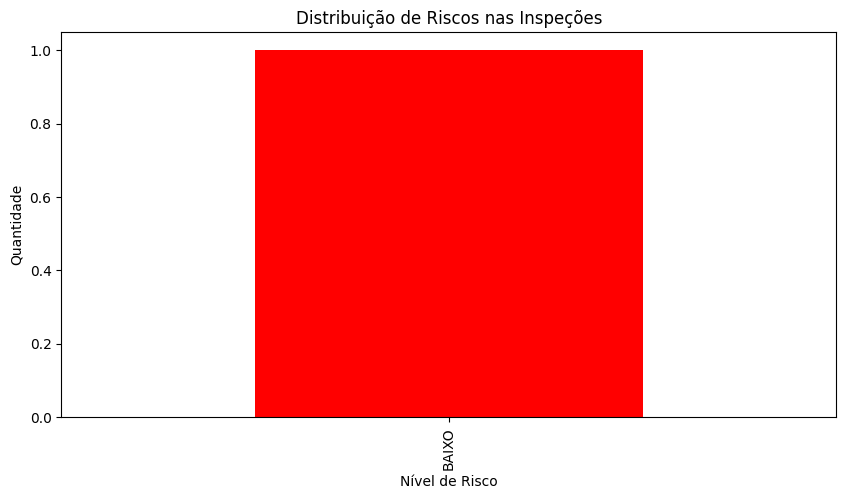

,arquivo,risco_classificado,resumo
0,/content/drive/MyDrive/inspecoes - pdf/2025-05...,BAIXO,\n\n \n\n \n\nVA_o0®& z\n\nCheck List Diario ...


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carrega os dados
df = pd.read_csv('/content/drive/MyDrive/inspecoes - pdf/dados_processados.csv')

# 2. Exibe o Dashboard diretamente no notebook
print("📊 DASHBOARD DE SEGURANÇA (SafetySentinel)")
print("-" * 40)
print(f"Total de Inspeções: {len(df)}")
print(f"Riscos Críticos: {len(df[df['risco_classificado'] == 'CRÍTICO'])}")

# 3. Gráfico rápido e limpo
plt.figure(figsize=(10, 5))
df['risco_classificado'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title("Distribuição de Riscos nas Inspeções")
plt.xlabel("Nível de Risco")
plt.ylabel("Quantidade")
plt.show()

# 4. Tabela de dados
display(df)